Found 400 successful raxml runs


1095it [00:00, 40044.67it/s]            
100%|██████████| 1000/1000 [00:00<00:00, 51908.42it/s]
1099it [00:00, 38838.44it/s]            
1095it [00:00, 31834.50it/s]            
1098it [00:00, 37896.59it/s]            
100%|██████████| 1000/1000 [00:00<00:00, 66886.27it/s]
1083it [00:00, 38235.31it/s]            
100%|██████████| 1000/1000 [00:00<00:00, 67308.10it/s]
1090it [00:00, 41103.25it/s]            
100%|██████████| 1000/1000 [00:00<00:00, 54412.12it/s]
1094it [00:00, 40812.31it/s]            
100%|██████████| 1000/1000 [00:00<00:00, 60289.84it/s]
1099it [00:00, 42688.04it/s]            
1098it [00:00, 38138.25it/s]            
1099it [00:00, 37861.94it/s]            
1088it [00:00, 38302.22it/s]            
1099it [00:00, 38220.14it/s]            
1098it [00:00, 39774.29it/s]            
100%|██████████| 1000/1000 [00:00<00:00, 50261.28it/s]
1099it [00:00, 36016.53it/s]            
1095it [00:00, 32983.09it/s]            
100%|██████████| 1000/1000 [00:00<00:00, 53328.72it/s]



Comparison ready: 400 runs


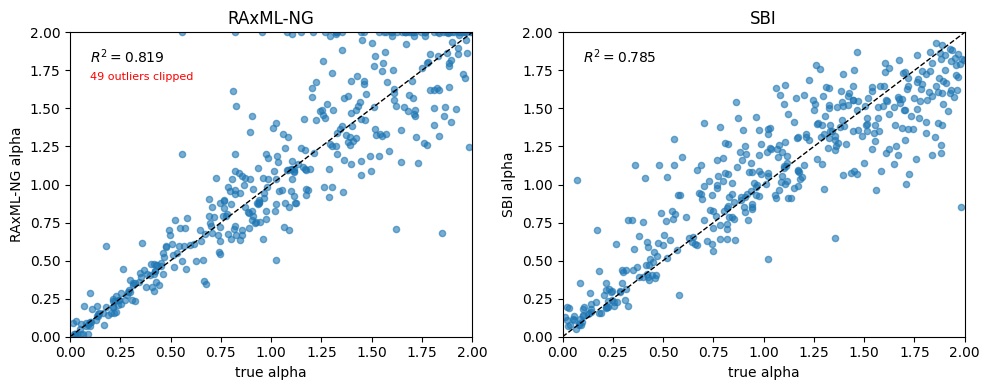

/tmp/ipykernel_43215/3546314482.py:109: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


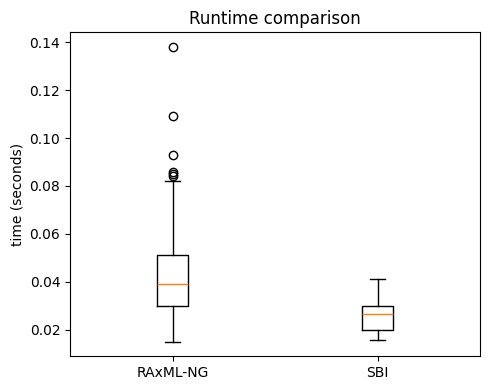

In [4]:
import pathlib
import time
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../sbi_pipeline")  # adjust to where features_calculator.py lives
from features_calculator import calculate_cnn_input

RAXML_RUNS_DIR = pathlib.Path("raxml_runs")
RAXML_RESULTS_CSV = pathlib.Path("results/inferred_parameters.csv")
GROUND_TRUTH_CSV = pathlib.Path("../codeml_benchmark/simulated_data/ground_truth.csv")
SIMULATED_DATA_DIR = pathlib.Path("../codeml_benchmark/simulated_data")
POST_PATH = "/home/elyalab/Dev/failed_syncs/rateAutoCorrelation/sbi_pipeline/sbi_models/posterior.pt"

# ── model def (must match training) ─────────────────────────────────────────
class CNN1dEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=5, padding=2), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=5, padding=2), nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x).mean(dim=-1)

# ── helpers ───────────────────────────────────────────────────────────────────
def read_phy(phy_path):
    lines = phy_path.read_text().strip().splitlines()
    seqs = []
    for line in lines[1:]:
        parts = line.split()
        if len(parts) >= 2:
            seqs.append(parts[1])
    return seqs

# ── load raxml results ────────────────────────────────────────────────────────
raxml_df = pd.read_csv(RAXML_RESULTS_CSV)
timing_df = pd.read_csv(RAXML_RUNS_DIR / "timing.csv")
raxml_df = raxml_df.merge(timing_df[["simulation", "time_seconds"]], left_on="sim_name", right_on="simulation")
raxml_df = raxml_df.rename(columns={"time_seconds": "raxml_time"})
print(f"Found {len(raxml_df)} successful raxml runs")

# ── load posterior ────────────────────────────────────────────────────────────
posterior = torch.load(POST_PATH, map_location="cpu", weights_only=False)

# ── run SBI on each sim ───────────────────────────────────────────────────────
sbi_rows = []
for sim_name in raxml_df["sim_name"]:
    phy_path = SIMULATED_DATA_DIR / sim_name / "alignment.phy"
    if not phy_path.exists():
        print(f"  WARNING: alignment not found for {sim_name}, skipping")
        continue

    seqs = read_phy(phy_path)
    seqs = [s[:500] for s in seqs]

    x_obs = calculate_cnn_input(seqs, alphabet_size=20).unsqueeze(0)

    t0 = time.time()
    with torch.no_grad():
        samples = posterior.sample((1000,), x=x_obs)
    sbi_elapsed = time.time() - t0

    alpha_median = samples[:, 0].median().item()
    alpha_std    = samples[:, 0].std().item()

    sbi_rows.append({"sim_name": sim_name, "sbi_alpha": alpha_median, "sbi_alpha_std": alpha_std, "sbi_time": sbi_elapsed})

sbi_df = pd.DataFrame(sbi_rows)

# ── join everything ───────────────────────────────────────────────────────────
gt_df = pd.read_csv(GROUND_TRUTH_CSV)
results = raxml_df.merge(sbi_df, on="sim_name").merge(gt_df, on="sim_name")
print(f"\nComparison ready: {len(results)} runs")

# ── scatter plot ──────────────────────────────────────────────────────────────
ALPHA_MAX = 2.0  # clip display to prior range

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, label in zip(axes, ["inferred_alpha", "sbi_alpha"], ["RAxML-NG", "SBI"]):
    mask = results[col] <= ALPHA_MAX
    n_outliers = (~mask).sum()
    clipped = results[col].clip(upper=ALPHA_MAX)
    ss_res = ((results.loc[mask, "true_alpha"] - results.loc[mask, col]) ** 2).sum()
    ss_tot = ((results.loc[mask, "true_alpha"] - results.loc[mask, "true_alpha"].mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    ax.scatter(results["true_alpha"], clipped, alpha=0.6, s=20)
    ax.plot([0, ALPHA_MAX], [0, ALPHA_MAX], "k--", lw=1)
    ax.set_xlim(0, ALPHA_MAX)
    ax.set_ylim(0, ALPHA_MAX)
    ax.set_xlabel("true alpha")
    ax.set_ylabel(f"{label} alpha")
    ax.set_title(label)
    ax.text(0.05, 0.95, f"$R^2 = {r2:.3f}$",
            transform=ax.transAxes, va="top", fontsize=10)
    if n_outliers > 0:
        ax.text(0.05, 0.87, f"{n_outliers} outliers clipped",
                transform=ax.transAxes, va="top", fontsize=8, color="red")
plt.tight_layout()
plt.show()

# ── runtime boxplot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(
    [results["raxml_time"].dropna(), results["sbi_time"]],
    labels=["RAxML-NG", "SBI"],
    showfliers=True,
)
ax.set_ylabel("time (seconds)")
ax.set_title("Runtime comparison")
plt.tight_layout()
plt.show()